In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import json
import torch
import torch.nn as nn
import seaborn as sns
import os
from dataProcesser import read_file_high_level, read_file_low_level , dicts_to_dataframe
from tqdm.notebook import tqdm
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from matplotlib.animation import FuncAnimation
from IPython.display import HTML
import ipywidgets as widgets
from IPython.display import clear_output
from typing import Dict, List
import joblib


processes = ['assembly', 'electronics', 'material-join', 'material-process']
device = 'cuda' if torch.cuda.is_available() else 'cpu'

torch.manual_seed(42)
print(f"Is CUDA available: {torch.cuda.is_available()}")
print(f"CUDA device count: {torch.cuda.device_count()}")


Is CUDA available: False
CUDA device count: 0


In [2]:
def get_pred(x, covariates, treatment, model, outcome):
    X = x[covariates].values
    T = x[treatment].values
    X_T = np.concatenate([X, T.reshape(-1, 1)], axis=1)
    X_T = torch.tensor(X_T, dtype=torch.float32).to(device)
    with torch.no_grad():
        predicted_effect = model(X_T).cpu().numpy()

    pred = []
    for effect in predicted_effect:
        pred.append(effect)
    
    pred = pd.DataFrame(pred, columns=outcome)
    return pred

def process_output(process: str, inventory: pd.DataFrame, module_inputs: List[pd.DataFrame], treatment_id) -> tuple:
    treatment = pd.DataFrame([treatment_id], columns='treatment_id')
    inputs = [inventory, treatment]
    inputs.extend(module_inputs)
    df = pd.concat(inputs, axis=1, join='inner')
    covariates = json.load(open(f'Models/Pytorch/LowLevel/{process}/covariates.json'))
    columns2check = list(df.columns)
    columns2check.append('treatment_id')
    for c in covariates:
        if c not in columns2check:
            newValue = pd.DataFrame(0, index=df.index, columns=[c])
            df = pd.concat([df, newValue], axis=1)
    df = df[covariates + ['treatment_id']]
    columns2scale = covariates.copy()
    outcome = json.load(open('Models/Pytorch/LowLevel/outcome.json'))
    ScalerIn = joblib.load(f'Models/Scalers/LowLevel/{process}/LowLevelScaler-Input.pkl')
    ScalerOut = joblib.load(f'Models/Scalers/LowLevel/{process}/LowLevelScaler-Outcome.pkl')
    model = torch.load(f'Models/Pytorch/LowLevel/{process}/{process}_depth_8.pth', map_location=device)
    df[columns2scale] = ScalerIn.transform(df[columns2scale])
    output = get_pred(df, covariates, 'treatment_id', model, outcome)
    output = ScalerOut.inverse_transform(output)
    output_time = output[outcome[0]]
    output_part = pd.DataFrame(output[outcome[1]], columns=[f'{process}_part'])
    return output_time, output_part

In [3]:
def assign_tree_depth(df1, df2):
    # Assuming df1 has 'query_id' and 'tree_depth' columns
    # and df2 has a 'query_id' column
    
    # Create a dictionary mapping query_id to tree_depth
    depth_dict = dict(zip(df1['query_id'], df1['tree_depth']))
    
    # Assign tree_depth to df2 based on query_id
    df2['tree_depth'] = df2['query_id'].map(depth_dict)
    
    return df2

In [4]:
df_lowLevel = []
df_HighLevel = pd.read_csv('csvs/factory_high_level.csv')

senarios = list(range(1, 51))
demands = list(range(5, 1005, 5))
workers = ['00', '01']

for scenario in tqdm(senarios):
    for demand in demands:
        for worker in workers:
            simulation_result = f'simulation_report/worker_{worker}/scenario_{scenario}/scenario_{scenario}_demand_{demand}_report.json'
            df_lowLevel.extend(read_file_low_level (simulation_result))

df_lowLevel = dicts_to_dataframe(df_lowLevel)
df_lowLevel['tree_depth'] =  0

df_lowLevel = assign_tree_depth(df_HighLevel, df_lowLevel)
df_lowLevel.head()

  0%|          | 0/50 [00:00<?, ?it/s]

,query_id,electronic_component,misc_component,fastener,treatment_id,material-join_part,raw_material,material-process_part,parts_produced_by_process,process_runtime,process_id,electronics_part,process,assembly_part,tree_depth
0,1_5,0,3,6,0,0,0,0,1,3.039569,assembly_1,1,assembly,1,4
1,1_5,1,1,1,0,0,0,0,1,4.190181,electronics_1,1,electronics,0,4
2,1_5,8,4,4,0,0,0,0,2,14.302546,electronics_3,0,electronics,0,4
3,1_5,0,10,8,0,2,0,2,2,7.963805,assembly_2,2,assembly,2,4
4,1_5,0,15,21,0,0,0,0,3,11.917544,assembly_3,0,assembly,0,4


In [5]:
class BaselineModel(nn.Module):
    def __init__(self, input_dim, output_dim):
        super(BaselineModel, self).__init__()
        self.ff_network = nn.Sequential(
            nn.Linear(input_dim, int(input_dim*1.5)),
            nn.ReLU(),
            nn.Linear(int(input_dim*1.5), input_dim*2),
            nn.ReLU(),
            nn.Linear(input_dim*2, input_dim),
            nn.ReLU(),
            nn.Linear(input_dim, int(input_dim/2) if input_dim/2>output_dim else output_dim),
            nn.ReLU(),
            nn.Linear(int(input_dim/2) if input_dim/2>output_dim else output_dim, output_dim)
        )

    def forward(self, x):
        return self.ff_network(x)

In [6]:
# def train_test_split_by_depth(df, train_depths, test_depths):
#     train_df = df[df['tree_depth'].isin(train_depths)]
#     test_df = df[df['tree_depth'].isin(test_depths)]
#     return train_df, test_df

# df_HighLevel = pd.read_csv('csvs/factory_high_level.csv')
# train_depths = [2, 3, 4, 5, 6, 7, 8]
# test_depths = [8]
# train_df, test_df = train_test_split_by_depth(df_lowLevel, train_depths, test_depths)
# train_qids = train_df['query_id'].unique()
# test_qids = test_df['query_id'].unique()    

import warnings
warnings.filterwarnings("ignore")
def get_train_test(df_low, knob_value, variable):
    print(knob_value, variable)
    hl_model_path = 'Models/Pytorch/HighLevel'
    with open(f'{hl_model_path}/{variable}/train_qids_{variable}_{knob_value}.json', 'r') as f:
        train_qids = json.load(f)
    with open(f'{hl_model_path}/{variable}/test_qids_{variable}_{knob_value}.json', 'r') as f:
        test_qids = json.load(f)
    with open(f'{hl_model_path}/{variable}/treatment_assignments_{variable}_{knob_value}.json', 'r') as f:
        treatment_assignments = json.load(f)
    
    test = df_low[df_low['query_id'].isin(test_qids)]
    train = df_low[df_low['query_id'].isin(train_qids)]
    
    train["treatment_assigned"] = train["query_id"].map(treatment_assignments)
    train = train[train["treatment_assigned"] == train["treatment_id"]]
    train = train.drop(columns=["treatment_assigned"])
    
    
    return train, test


In [8]:
def get_scaler_feature_names(scaler):
    """
    Extract column names from a fitted scikit-learn scaler object.
    
    Parameters:
    scaler: A fitted scikit-learn scaler (StandardScaler, MinMaxScaler, RobustScaler, etc.)
    
    Returns:
    list: List of feature names used during fitting
    
    Raises:
    ValueError: If scaler is not fitted or feature names are not available
    """
    if not hasattr(scaler, 'n_features_in_'):
        raise ValueError("Scaler is not fitted yet. Please fit the scaler first.")
    
    # Try different attribute names where feature names might be stored
    feature_names = None
    
    # Check if feature names were passed during fit
    if hasattr(scaler, 'feature_names_in_'):
        feature_names = list(scaler.feature_names_in_)
    
    # For older scikit-learn versions or if names weren't passed
    elif hasattr(scaler, '_feature_names_in'):
        feature_names = list(scaler._feature_names_in)
    
    # If no feature names found, return generic names
    if feature_names is None:
        feature_names = [f'feature_{i}' for i in range(scaler.n_features_in_)]
    
    return feature_names

In [10]:
processes = list(set(df_lowLevel.process))
variable = 'tree_depth'
outcome = json.load(open(f'Models/Pytorch/LowLevel/outcome.json'))
print(f"Outcome: {outcome}")
train_qids = []
test_qids = []
train_data = {}
test_data = {}
module_covariates = {}
module_scalersIn = {}
module_scalersOut = {}
train_test_split_type = "tree_depth"
obs_biasing_type = "random"
if train_test_split_type == "tree_depth":
    knob_values = [3, 4, 5, 6, 7, 8]
    variable = 'tree_depth'
else:
    knob_values = [0]
    variable = 'bias_strength'
hl_model_path = 'Models/Pytorch/HighLevel'
train_test_split_type = 'tree_depth'
for process in processes:
    df_low = pd.read_csv(f'csvs/{process}_low_level.csv')
    # covs = json.load(open(f'Models_new/Pytorch/LowLevel/{process}/covariates.json'))
    scalerIn = joblib.load(f'Models_new/Scalers/LowLevel/{process}/LowLevelScaler-Input.pkl')
    scalerOut = joblib.load(f'Models_new/Scalers/LowLevel/{process}/LowLevelScaler-Outcome.pkl')
    covs = list(get_scaler_feature_names(scalerIn))
    for knob_value in knob_values:
        train, test = get_train_test(df_low, knob_value, variable)
        
        train_qids.extend(train['query_id'].values)
        test_qids.extend(test['query_id'].values)
        train_data[process] = train
        test_data[process] = test
        module_covariates[process] = covs
        module_scalersIn[process] = scalerIn
        module_scalersOut[process] = scalerOut

train_qids = list(set(train_qids))
test_qids = list(set(test_qids))
print(f"Number of train queries: {len(train_qids)}")
print(f"Number of test queries: {len(test_qids)}")



Outcome: ['parts_produced_by_process']
3 tree_depth
4 tree_depth
5 tree_depth
6 tree_depth
7 tree_depth
8 tree_depth
3 tree_depth
4 tree_depth
5 tree_depth
6 tree_depth
7 tree_depth
8 tree_depth
3 tree_depth
4 tree_depth
5 tree_depth
6 tree_depth
7 tree_depth
8 tree_depth
3 tree_depth
4 tree_depth
5 tree_depth
6 tree_depth
7 tree_depth
8 tree_depth
Number of train queries: 10000
Number of test queries: 2200


In [11]:

from concurrent.futures import ThreadPoolExecutor, as_completed
class ScenarioNode:
    def __init__(self, module_id, module_name, features, feature_names, outputs, output_names, children=None, children_name=None):
        self.module_id = module_id
        self.module_name = module_name
        self.features = features
        self.feature_names = feature_names
        self.outputs = outputs
        self.output_names = output_names
        self.children = children if children is not None else []
        self.children_name = children_name if children_name is not None else []
    def to_dict(self):
        node_dict = {
            "module_id": self.module_id,
            "module_name": self.module_name,
            "features": self.features,
            "feature_names": self.feature_names,
            "outputs": self.outputs,
            "output_names": self.output_names
        }
        if self.children:
            node_dict["children"] = [child.to_dict() for child in self.children]
        else:
            node_dict["children"] = None
        return node_dict

def get_children_dependencies(assembly_sequence):
    children_dependency = {}
    
    for i in np.arange(len(assembly_sequence)-1, -1, -1):
        modules = assembly_sequence[i]
        for module in modules:
            process_id = module["process_id"]
            child = module["wip_output_to"]
            if child != None:
                if child not in children_dependency:
                    children_dependency[child] = [process_id]
                else:
                    children_dependency[child].append(process_id)
    return children_dependency

def get_children_nodes(assembly_sequence):
    children_nodes = {}
    max_depth = len(assembly_sequence)
    for i in np.arange(max_depth-1, -1, -1):
        modules = assembly_sequence[i]
        for module in modules:
            module_id = module["name"]
            module_name = module["process_id"]
            inventory_features = []
            WIP_features = []
            inventory_feature_names = []
            wip_feature_names = []
            for item in module["inventory_input_items"]:
                inventory_features.append(item)
                inventory_feature_names.append(item)
            for item in module["WIP_input_items"]:
                WIP_features.append(item)
                wip_feature_names.append(item)
            features = inventory_features + WIP_features
            feature_names = inventory_feature_names + wip_feature_names
            outputs = None
            output_names = module["output_item"]
            children = []
            children_name = []
            node = ScenarioNode(module_id, module_name, features, feature_names, outputs, output_names, children, children_name)
            if module_name not in children_nodes:
                children_nodes[module_name] = node
            else:
                children_nodes[module_name].append(node)
    return children_nodes


def get_scenario_tree(assembly_sequence):
    # start from last module
    # assembly sequence is a list of list containing dictionaries
    # each list contains the modules that are executed in parallel

    # create a list of ScenarioNode objects

    children_dependency = get_children_dependencies(assembly_sequence)
    children_nodes = get_children_nodes(assembly_sequence)
    # print(children_dependency)
    max_depth = len(assembly_sequence)
    # now based on children_dependency, create a tree
    root = None
    for i in np.arange(0, max_depth):
        modules = assembly_sequence[i]
        if i == max_depth - 1:
            assert len(modules) == 1
            module = modules[0]
            process_id = module["process_id"]
            root = children_nodes[process_id]
            for child in children_dependency[process_id]:
                root.children.append(children_nodes[child])
                root.children_name.append(child)
        else:
            for module in modules:
                process_id = module["process_id"]
                if process_id in children_dependency:
                    for child in children_dependency[process_id]:
                        children_nodes[process_id].children.append(children_nodes[child])
                        children_nodes[process_id].children_name.append(child)

    
    return root.to_dict()

def print_tree(node, depth):
    print("\t"*depth, node.module_name)
    for child in node.children:
        print_tree(child, depth+1)
    
def create_scenario_node_from_initial_conditions(cond_json_dict, scenario_id, treatment_id):
    scenario_dict = {"scenario_id": scenario_id, "treatment_id": treatment_id}
    assembly_sequence = cond_json_dict["assembly_sequence"]
    json_tree = get_scenario_tree(assembly_sequence)
    scenario_dict["json_tree"] = json_tree
    return scenario_dict


def get_pred(x, covariates, treatment, model):
    X = x[covariates].values
    T = x[treatment].values
    X_T = np.concatenate([X, T.reshape(-1, 1)], axis=1)
    # print(X_T.shape)
    X_T = torch.tensor(X_T, dtype=torch.float32).to(device)
    with torch.no_grad():
        predicted_effect = model(X_T).cpu().numpy()

    # pred = []
    # for effect in predicted_effect:
    
    #     pred.append(effect)
    return predicted_effect

def get_gt (x, outcome):
    return x[outcome]

def predict(node, query_id, treatment_id, trained_models, test_data_dict, outcome):
    module_id = node["module_id"]
    module_name = node["module_name"]
    model = trained_models[module_id]
    df = test_data_dict[module_id]
    module_row = df[df["query_id"] == query_id]
    module_row = module_row[module_row["process_id"] == module_name]
    module_row = module_row[module_row["treatment_id"] == treatment_id]
    # print(len(module_row), module_id, module_name)
    module_covs = module_covariates[module_id]
    scalerIn = module_scalersIn[module_id]
    scalerOut = module_scalersOut[module_id]

    if node["children"] is not None: 
        for child in node["children"]:
            child = node["children"][0]
            child_module_id = child["module_id"]
            child_output = predict(child, query_id, treatment_id, trained_models, test_data_dict, outcome)
            child_output_name = child["module_id"] + "_part"
            # print(child_output_name, child_output)
            # inverse transform the child output
            outcome_dim = len(outcome)
            scaled_child_output = module_scalersOut[child_module_id].inverse_transform(child_output.reshape(-1, outcome_dim))[0]
            # print(scaled_child_output[-1], module_row[child_output_name], child_output_name)
            
            
            module_row = module_row.assign(child_output_name = scaled_child_output[-1]) # assuming last output is the parts produced
    module_row[module_covs] = scalerIn.transform(module_row[module_covs])
    pt = get_pred(module_row, module_covs, 'treatment_id', model)
    pt = scalerOut.inverse_transform(pt.reshape(-1, len(outcome)))

    return pt[0]

def predict_single_query(args):
    query_id, json_dict, trained_models, test_data_dict, outcome = args
    tree_node = json_dict["json_tree"]
    p1 = predict(tree_node, query_id, 1, trained_models, test_data_dict, outcome)
    p0 = predict(tree_node, query_id, 0, trained_models, test_data_dict, outcome)
    return query_id, p1, p0

def predict_modular_model_with_po(test_data, trained_models, jsons, outcome):
    predictions_1 = {}
    predictions_0 = {}

    # Convert test_data to a dictionary for faster access
    test_data_dict = {file: df for file, df in test_data.items()}

    # Use ThreadPoolExecutor for parallel processing
    with ThreadPoolExecutor(max_workers=8) as executor:
        futures = []
        for query_id, json_dict in tqdm(jsons.items(), desc="Creating futures"):
            futures.append(executor.submit(predict_single_query, (query_id, json_dict, trained_models, test_data_dict, outcome)))

        for future in tqdm(as_completed(futures), total=len(futures), desc="Processing queries"):
            query_id, prediction_1, prediction_0 = future.result()
            predictions_1[query_id] = prediction_1
            predictions_0[query_id] = prediction_0

    # for query_id, json_dict in tqdm(jsons.items(), desc="Processing queries"):
    #     query_id, predictions_1[query_id], predictions_0[query_id] = predict_single_query((query_id, json_dict, trained_models, test_data_dict, outcome))

    return predictions_1, predictions_0


In [12]:
def get_pred_gt_effect(df_apo, outcome):
    gt_effects = {}
    df1 = df_apo[df_apo['treatment_id'] == 1]
    df0 = df_apo[df_apo['treatment_id'] == 0]
    df1 = df1[['query_id', outcome]]
    df0 = df0[['query_id', outcome]]
    # merge the two dataframes on query_id
    df_apo = pd.merge(df1, df0, on='query_id', suffixes=('_1', '_0'))
    effect = df_apo[outcome + '_1'] - df_apo[outcome + '_0']
    for i, qid in enumerate(df_apo['query_id']):
        gt_effects[qid] = effect[i]
    return gt_effects

def get_effect(predictions_1, predictions_0):
    effect = {}
    for qid in predictions_1:
        effect[qid] = predictions_1[qid][0] - predictions_0[qid][0]
    return effect

In [13]:
df_HighLevel = pd.read_csv('csvs/factory_high_level.csv')
gt_effects = get_pred_gt_effect(df_HighLevel, 'total_output')
# df_HighLevel.head()

In [ ]:
variable = "tree_depth"
test_queries = test_qids[:100]
test_queries
initial_conditions_file_path = '/Users/ppruthi/research/compositional_models/compositional_models_cate/factory_final/initial_conditions'
structure_jsons = {}
# read data for test queries
for qid in test_queries:
    scenario_id, demand = qid.split('_')[0], qid.split('_')[1]
    # print(f"Scenario ID: {scenario_id}, Demand: {demand}")
    json_file = f"{initial_conditions_file_path}/scenario_{scenario_id}/scenario_{scenario_id}_demand_{demand}.json"
    with open(json_file) as f:
        initial_conditions = json.load(f)
    scenario_dict = create_scenario_node_from_initial_conditions(initial_conditions, scenario_id, demand)
    structure_jsons[qid] = scenario_dict


gt_effect = get_pred_gt_effect(df_HighLevel, 'total_output')
train_effect_csvs = {}
mses = []
r2s = []
for knob_value in knob_values:
    trained_models = {}
    for process in processes:
        model = torch.load(f'Models/Pytorch/LowLevel/{process}/LowLevelModel_{variable}_{knob_value}.pt', map_location=device)
        # model = torch.load(f'Models_new/Pytorch/LowLevel/{process}/{process}_depth_{knob_value}.pth', map_location=device)
        trained_models[process] = model
    # trained_subdata = train_data[train_data['tree_depth'] <= knob_value]
    predictions_1, predictions_0 = predict_modular_model_with_po(test_data, trained_models, structure_jsons, outcome)
    pred_effect = get_effect(predictions_1, predictions_0)
    pred_df = pd.DataFrame(pred_effect.items(), columns=['query_id', 'predicted_effect'])
    gt_df = pd.DataFrame(gt_effect.items(), columns=['query_id', 'gt_effect'])
    df_merged = pd.merge(pred_df, gt_df, on='query_id')
    train_effect_csvs[knob_value] = df_merged
    mse = mean_squared_error(df_merged['gt_effect'], df_merged['predicted_effect'])
    r2 = r2_score(df_merged['gt_effect'], df_merged['predicted_effect'])
    print(f"{variable}: {knob_value}")
    print(f"MSE: {mse}")
    print(f"R2: {r2}")
    mses.append(mse)
    r2s.append(r2)

# plt.figure(figsize=(20,10))
# plt.plot(depths, mses, label='MSE')
# plt.title('Model MSE score variation with depth')
# plt.xlabel(f'{variable}')
# plt.ylabel('MSE')
# plt.legend()
# plt.show()

# plt.figure(figsize=(20,10))
# plt.plot(depths, r2s, label='R2')
# plt.title('Model R2 score variation with depth')
# plt.xlabel(f'{variable}')
# plt.ylabel('R2')
# plt.legend()
# plt.show()

Creating futures:   0%|          | 0/100 [00:00<?, ?it/s]

Processing queries:   0%|          | 0/100 [00:00<?, ?it/s]

tree_depth: 3
MSE: 3745.7697201388432
R2: 0.6432985067367554


Creating futures:   0%|          | 0/100 [00:00<?, ?it/s]

Processing queries:   0%|          | 0/100 [00:00<?, ?it/s]

3
Mean Square Error Test: 1215.6754030786972
r2 score Test: 0.8758368492126465
4
Mean Square Error Test: 700.0192632307954
r2 score Test: 0.9285034537315369
5
Mean Square Error Test: 160.65931431358786
r2 score Test: 0.9835910201072693
6
Mean Square Error Test: 1537.5089838582958
r2 score Test: 0.8429663777351379
7
Mean Square Error Test: 257.71091971409044
r2 score Test: 0.9736786484718323
8
Mean Square Error Test: 73.38126412268225
r2 score Test: 0.9925051927566528


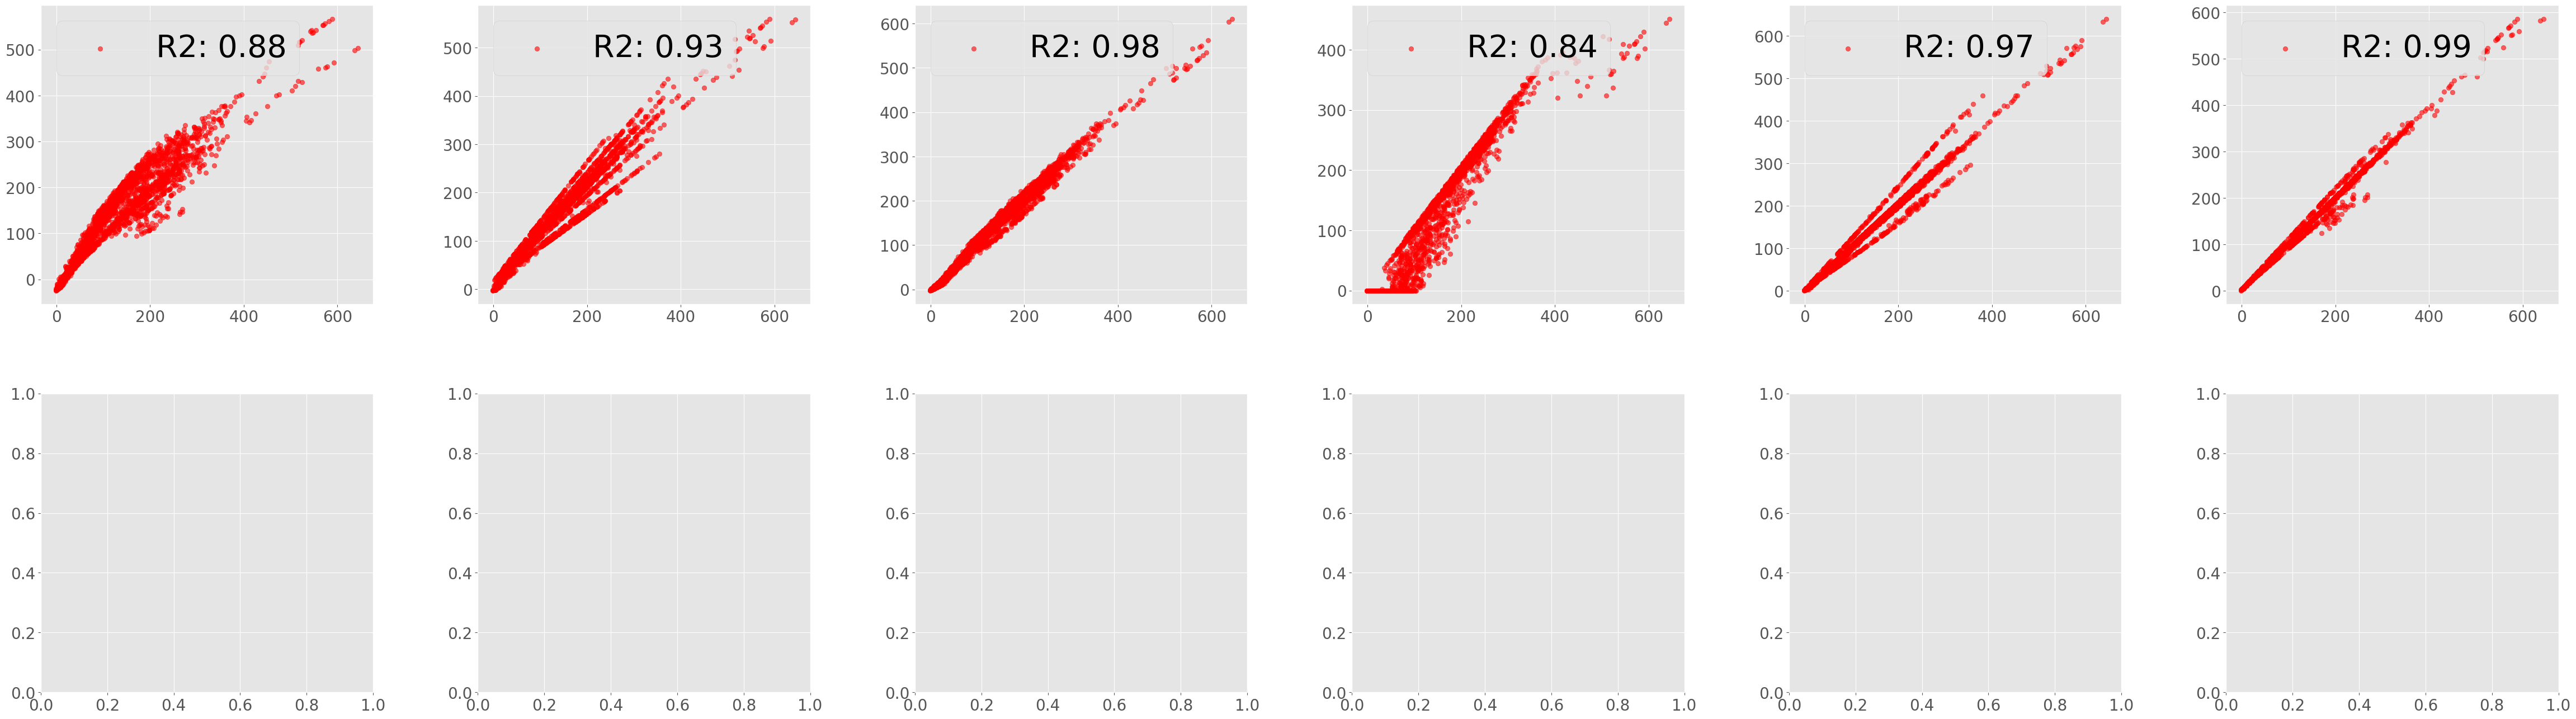

In [24]:
# Define the number of subplots based on the number of keys in dictOfModels_HH
font_size = 20
plt.rcParams.update({'font.size': font_size})
plt.rcParams.update({'legend.fontsize': 40})
plt.rcParams.update({'axes.labelsize': font_size})
plt.rcParams.update({'axes.titlesize': font_size})
markersize = 10
num_depths = len(knob_values)
fig, axes = plt.subplots(nrows=2, ncols=num_depths, figsize=(8 * num_depths, 15))
fig.tight_layout(pad=4.0)

for idx, knob_value in enumerate([3, 4, 5, 6, 7, 8]):
    test_df_effect = effect_csvs[knob_value]
    # # model = torch.load(dictOfModels_HL[knob_value], weights_only=False)
    # train, test = get_train_test_from_file(df_scaled, knob_value, variable)
    # train_estimates = x_learner(train, covariates, treatment, outcome[0], X_test=train, output_scaler=output_scaler)
    # test_estimates = x_learner(train, covariates, treatment, outcome[0], X_test=test, output_scaler=output_scaler)
    # gt_effects = get_pred_gt_effect(df_apo, outcome[0])
    # train_estimates = {train['query_id'].iloc[i]: train_estimates[i] for i in range(len(train_estimates))}
    # test_estimates = {test['query_id'].iloc[i]: test_estimates[i] for i in range(len(test_estimates))}
    # test_pred_df = pd.DataFrame(list(test_estimates.items()), columns=['query_id', 'predicted_effect'])
    # test_actual_df = pd.DataFrame(list(gt_effects.items()), columns=['query_id', 'actual_effect'])
    # test_df_effect = pd.merge(test_pred_df, actual_df, on='query_id')

    # train_pred_df = pd.DataFrame(list(train_estimates.items()), columns=['query_id', 'predicted_effect'])
    # train_actual_df = pd.DataFrame(list(gt_effects.items()), columns=['query_id', 'actual_effect'])
    # train_df_effect = pd.merge(train_pred_df, actual_df, on='query_id')

    # pred_test_effect = get_pred_effect(test, covariates, treatment, model, output_scaler)
    # actual_test_effect = get_pred_gt_effect(df_apo, outcome[0])
    
    # pred_train_effect = get_pred_effect(train, covariates, treatment, model, output_scaler)
    # actual_train_effect = get_pred_gt_effect(df_apo, outcome[0])
    
    # train_pred_df = pd.DataFrame(list(pred_train_effect.items()), columns=['query_id', 'predicted_effect'])
    # train_actual_df = pd.DataFrame(list(actual_train_effect.items()), columns=['query_id', 'actual_effect'])


    # test_pred_df = pd.DataFrame(list(pred_test_effect.items()), columns=['query_id', 'predicted_effect'])
    # test_actual_df = pd.DataFrame(list(actual_test_effect.items()), columns=['query_id', 'actual_effect'])
    # train_df_effect = pd.merge(train_pred_df, train_actual_df, on='query_id')
    # test_df_effect = pd.merge(test_pred_df, test_actual_df, on='query_id')

    # pred_test = get_pred(train, covariates, treatment, model)
    # actual_test = get_pred_gt(train)
    # pred_train = get_pred(test, covariates, treatment, model)
    # actual_train = get_pred_gt(test)

    # Scatter plot for training data in the first row
    # ax_train = axes[0, idx] if num_depths > 1 else axes[0]  # Adjust for single or multiple subplots
    # ax_train.scatter(train_df_effect['actual_effect'], train_df_effect['predicted_effect'], label='Train', color='blue', alpha=0.6)
    # # ax_train.set_xlabel('Actual')
    # # ax_train.set_ylabel('Predicted')
    # # ax_train.set_title(f'Train Data - Tree Depth: {knob_value}')
    # ax_train.legend()

    # Scatter plot for test data in the second row
    ax_test = axes[0, idx]
    ax_test.scatter(test_df_effect['gt_effect'], test_df_effect['predicted_effect'], label='Test', color='red', alpha=0.6)
    # ax_test.set_xlabel('Actual')
    # ax_test.set_ylabel('Predicted')
    # ax_test.set_title(f'Test Data - Tree Depth: {knob_value}')
    ax_test.legend()

    print(knob_value)
    # print(f'Mean Square Error Train: {mean_squared_error(train_df_effect["actual_effect"], train_df_effect["predicted_effect"])}')
    print(f'Mean Square Error Test: {mean_squared_error(test_df_effect["gt_effect"], test_df_effect["predicted_effect"])}')

    # print(f'r2 score Train: {r2_score(train_df_effect["actual_effect"], train_df_effect["predicted_effect"])}')
    print(f'r2 score Test: {r2_score(test_df_effect["gt_effect"], test_df_effect["predicted_effect"])}')
    # include R2 score as legend with 2 decimal places
    # ax_train.legend([f'R2: {r2_score(train_df_effect["gt_effect"], train_df_effect["predicted_effect"]):.2f}'])
    ax_test.legend([f'R2: {r2_score(test_df_effect["gt_effect"], test_df_effect["predicted_effect"]):.2f}'])
    
plt.savefig('scatter_plot_low_level.pdf', bbox_inches='tight')

In [14]:
results_ll = {}
results_ll['mses'] = mses
results_ll['r2s'] = r2s
with open(f'Models/Pytorch/LowLevel/results_ll_sample_size_more_fine_grained.json', 'w') as f:
    json.dump(results_ll, f)

In [34]:
# tree depths
with open("/Users/ppruthi/research/compositional_models/compositional_models_cate/factory_final/Models/Pytorch/LowLevel/results_ll.json", "r") as f:
    results_ll_depth = json.load(f)

with open("/Users/ppruthi/research/compositional_models/compositional_models_cate/factory_final/Models/Pytorch/HighLevel/tree_depth/high_level_models_tree_depth.json", "r") as f:
    dictOfModels_depth = json.load(f)

In [ ]:
# tree depths
with open("/Users/ppruthi/research/compositional_models/compositional_models_cate/factory_final/Models/Pytorch/LowLevel/results_ll_bias_strength.json", "r") as f:
    results_ll_bs = json.load(f)


{'low_level_bias_strength_0': {'error': 452.4600473808923,
  'r2': 0.9343025088310242},
 'low_level_bias_strength_1': {'error': 82.58051885363052,
  'r2': 0.9880092740058899},
 'low_level_bias_strength_2': {'error': 40.77334094498074,
  'r2': 0.9940797090530396},
 'low_level_bias_strength_5': {'error': 211.97587299169646,
  'r2': 0.9692209959030151},
 'low_level_bias_strength_10': {'error': 826.2296073307768,
  'r2': 0.8800309896469116},
 'low_level_bias_strength_3': {'error': 41.83937429576251,
  'r2': 0.9939249157905579},
 'low_level_bias_strength_4': {'error': 15.53699631276216,
  'r2': 0.9977440237998962},
 'low_level_bias_strength_6': {'error': 48.90863877660257,
  'r2': 0.9928984642028809},
 'low_level_bias_strength_7': {'error': 177.08023361311876,
  'r2': 0.9742878675460815},
 'low_level_bias_strength_8': {'error': 485.34080800733193,
  'r2': 0.9295282363891602},
 'low_level_bias_strength_9': {'error': 333.0802137175129,
  'r2': 0.951636552810669}}

In [36]:
# # save dictOfModels to a file as json object
with open(f"Models/Pytorch/HighLevel/bias_strength/high_level_models_bias_strength.json", "r") as f:
    dictOfModels_bias_strength = json.load(f)
bias_strengths = [0.0, 1, 2, 3,4,5,6,7,8,9,10]
variable = 'bias_strength'
for model_name in ['tnet', 'random_forest', 'non_param_DML', 'x_learner', 'neural_net']:
    for knob_value in bias_strengths:
        model_result = dictOfModels_bias_strength[f"{model_name}_{variable}_{int(knob_value)}"]
        mse, r2 = model_result.split('_')
        if float(r2) < 0:
            r2 = 0
        r2 = float(r2)
        dictOfModels_bias_strength[f"{model_name}_{variable}_{int(knob_value)}"] = {'error': mse, 'r2': r2}


for i, knob_value in enumerate(bias_strengths):
    dictOfModels_bias_strength[f'low_level_{variable}_{int(knob_value)}'] = results_ll_bs[f'low_level_{variable}_{int(knob_value)}']

depths = [3, 4, 5, 6, 7, 8]
variable = 'depth'
for i, knob_value in enumerate(depths):
    dictOfModels_depth[f'low_level_{variable}_{int(knob_value)}'] = {'error': results_ll_depth['mses'][i], 'r2': results_ll_depth['r2s'][i]}


with open(f"Models/Pytorch/HighLevel/bias_strength/DML_bias_strength.json", "r") as f:
    dml_results = json.load(f)

with open(f"Models/Pytorch/HighLevel/bias_strength/DML_real_bias_strength.json", "r") as f:
    dml_real_results = json.load(f)

# update dictOfModels_bias_strength with DML results with same key
for key, value in dml_results.items():
    if value['r2'] < 0:
        value['r2'] = 0
    dictOfModels_bias_strength[key] = value

# update dictOfModels_bias_strength with DML results with same key
for key, value in dml_real_results.items():
    if value['r2'] < 0:
        value['r2'] = 0
    dictOfModels_bias_strength[key] = value


# # update dictOfModels_bias_strength with DML results
# for i, knob_value in enumerate(bias_strengths):
#     # if value is negative, set it to 0
#     if dml_results[f'non_param_DML_bias_strength_{int(knob_value)}']['r2'] < 0:
#         dml_results[f'non_param_DML_bias_strength_{int(knob_value)}']['r2'] = 0
    
#     dictOfModels_bias_strength[f'non_param_DML_bias_strength_{int(knob_value)}'] = dml_results[f'non_param_DML_bias_strength_{int(knob_value)}']


In [37]:
with open(f"/Users/ppruthi/research/compositional_models/compositional_models_cate/factory_final/Models/Pytorch/HighLevel/high_level_sample_size_error.json", "r") as f:
    dictOfModels_sample_size = json.load(f)

In [47]:
# add results_ll

for i, knob_value in enumerate([0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]):
    dictOfModels_sample_size[f'low_level_sample_size_{knob_value}'] = {'error': results_ll['mses'][i], 'r2': results_ll['r2s'][i]}
dictOfModels_sample_size

# save dictOfModels to a file as json object
with open(f"Models/Pytorch/HighLevel/high_level_sample_size_error.json", "w") as f:
    json.dump(dictOfModels_sample_size, f)

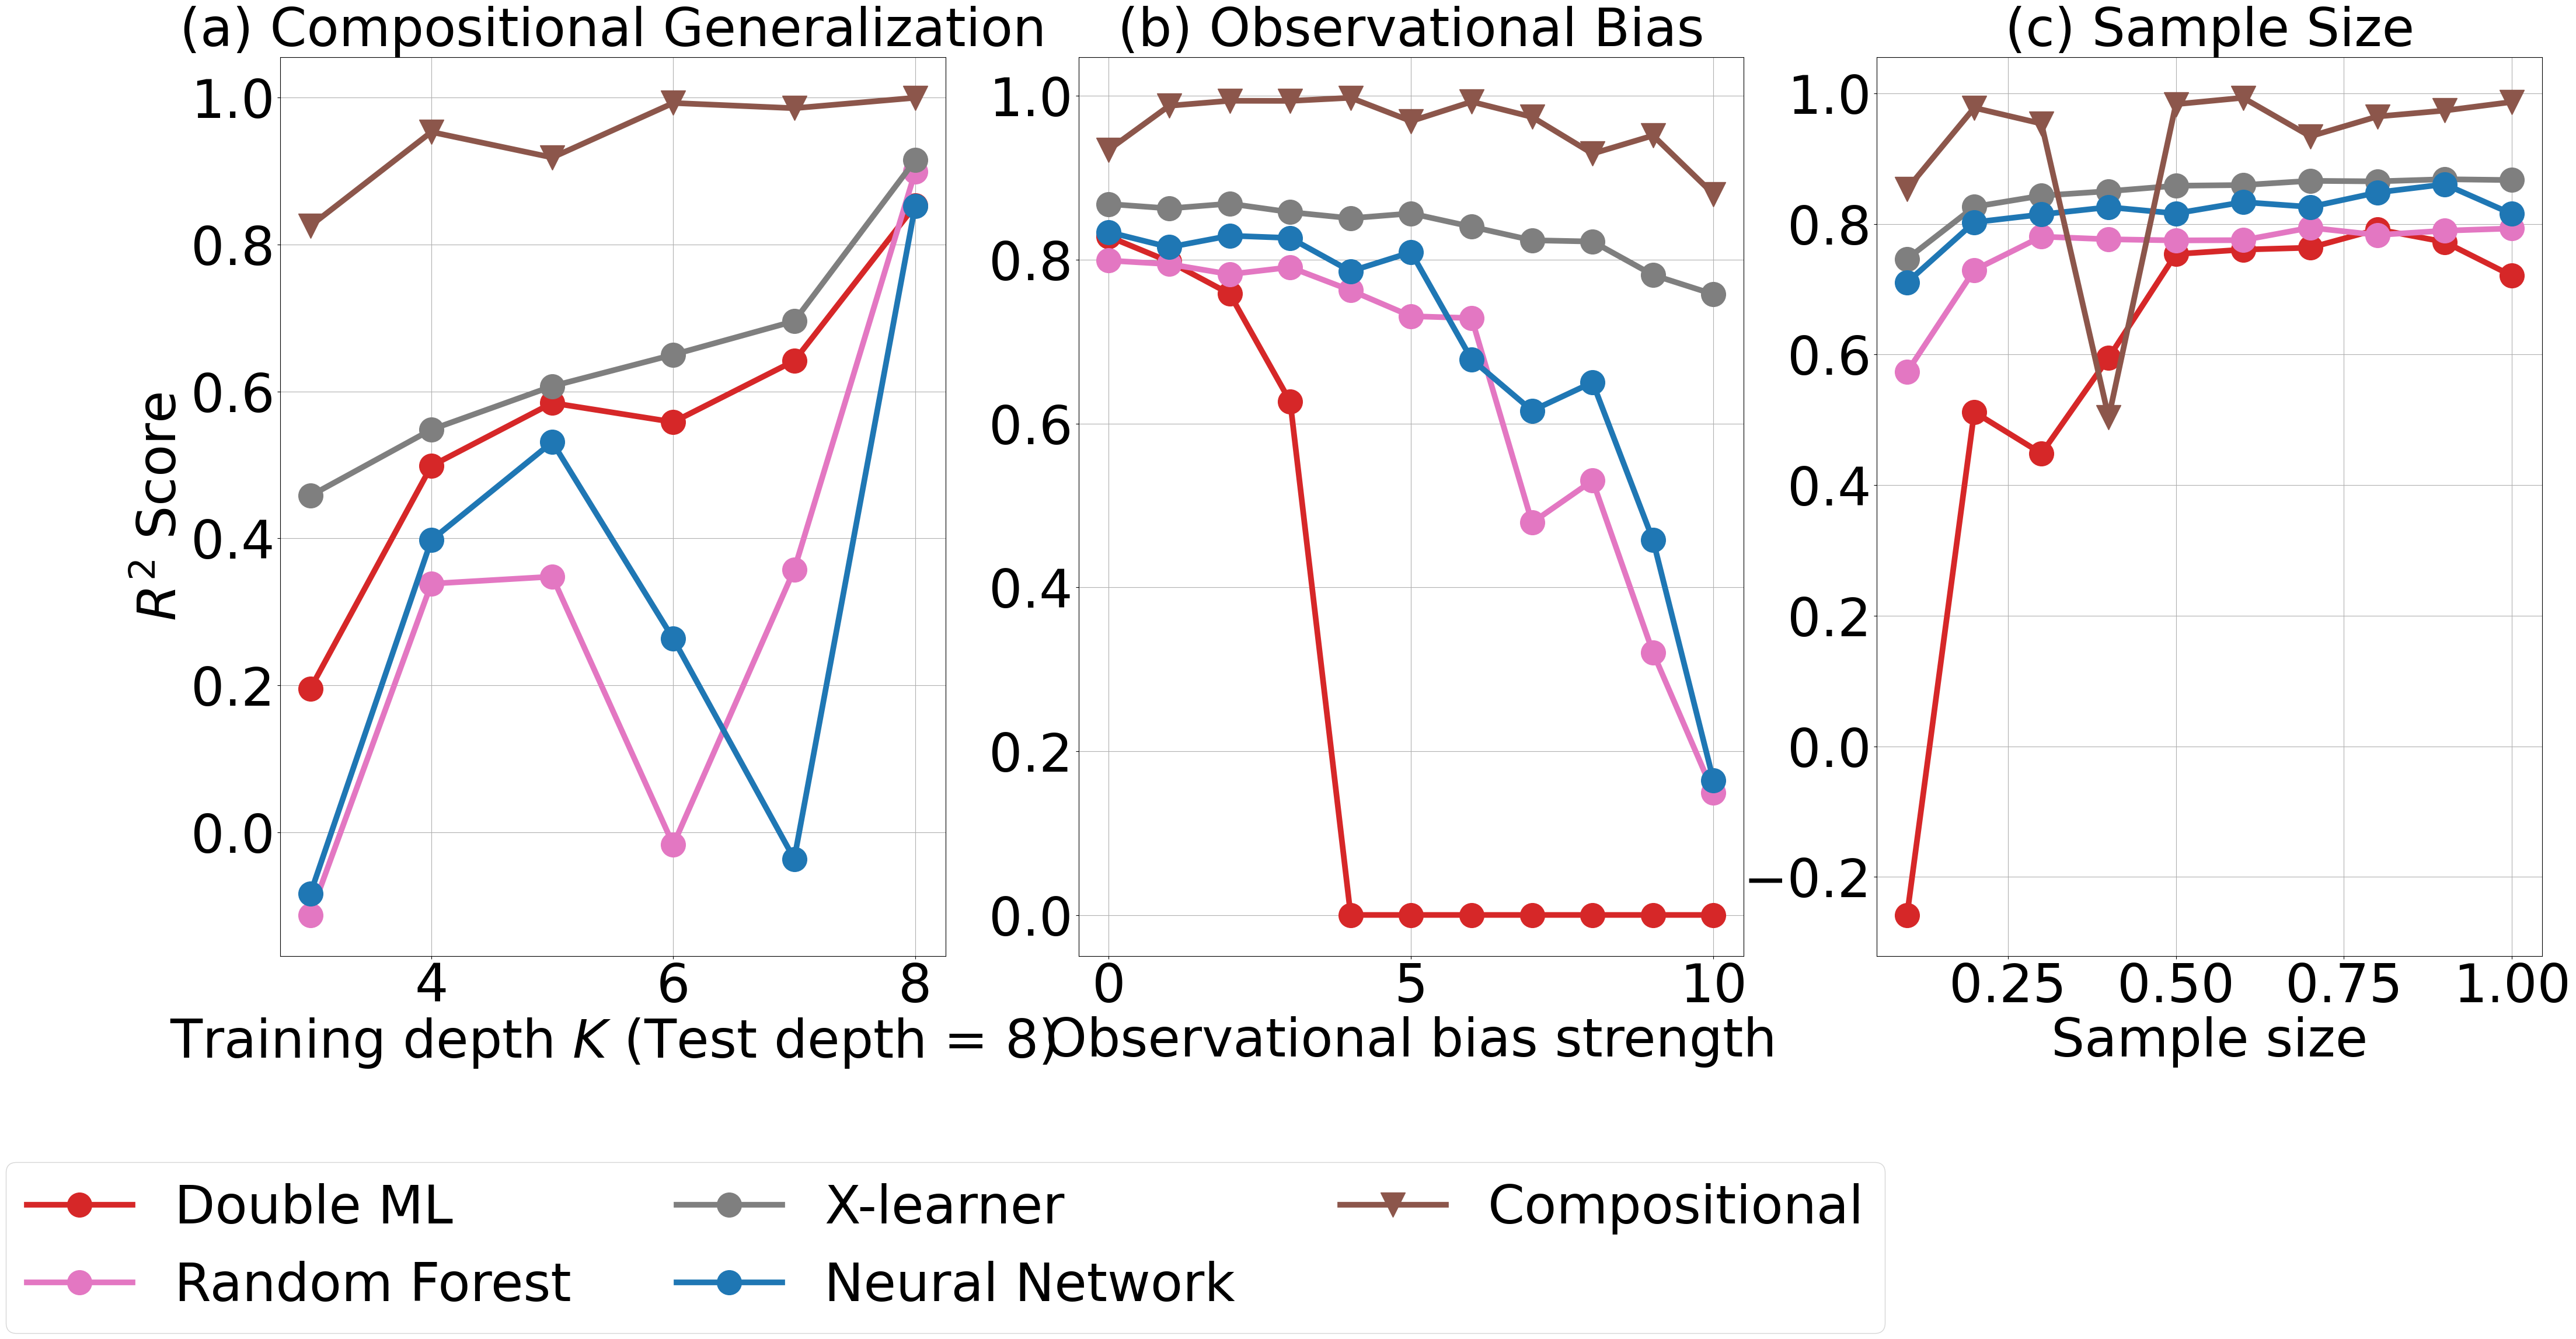

In [39]:
# whitegrid
label_colors = {"neural_network": '#1f77b4',
                "recursive_single_outcome": '#ff7f0e',
                "recursive_all_outcomes": '#2ca02c',
                "modular_single_outcome": '#17becf',
                "modular_all_outcomes": '#9467bd',
                "random_forest_additive": '#8c564b',
                "neural_network_additive": '#1f77b4',
                "x_learner": '#7f7f7f',
                "s_learner": '#bcbd22',
                "t_learner":  '#17becf',
                "random_forest": '#e377c2',
                "non_param_DML": '#d62728',
                "snet1": '#8c564b',
                "snet2": '#d62728',
                "tnet": '#bcbd22',
                "low_level": "#8c564b",
                "neural_net": '#1f77b4'}
markersize = 30
linewidth = 7
font_size = 65
plt.rcParams.update({'font.size': font_size})
plt.rcParams.update({'legend.fontsize': font_size})
plt.rcParams.update({'axes.labelsize': font_size})
plt.rcParams.update({'axes.titlesize': font_size})
label_names = {'random_forest': 'Random Forest', 'x_learner': 'X-learner', 'non_param_DML': 'Double ML', 'neural_net': 'Neural Network', 'low_level': r'Compositional', 's_learner': 'S-learner', 't_learner': 'T-learner'}

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(50, 20))
for model_name in ['non_param_DML', 'random_forest','x_learner',  'neural_net', 'low_level']:
    depth_error = []
    depth_r2 = []
    for depth in [3, 4, 5, 6, 7, 8]:
        if model_name == 'low_level':
            variable = 'depth'
        else:
            variable = 'tree_depth'
        label_name = label_names[model_name]
        depth_error.append(dictOfModels_depth[f'{model_name}_{variable}_{int(depth)}']['error'])
        depth_r2.append(dictOfModels_depth[f'{model_name}_{variable}_{int(depth)}']['r2'])
    
    # ax1.plot(depths, error, label=f'{model_name}', marker='o')
    depth_error_sqrt = [np.sqrt(x) for x in depth_error]
    if model_name == 'low_level':
        marker = 'v'
    else:
        marker = 'o'
    ax1.plot(depths, depth_r2, label=label_name, marker=marker, color=label_colors[model_name], markersize=markersize, linewidth=linewidth)

    
    variable = 'bias_strength'
    bs_error = []
    bs_r2 = []
    for bias_strength in bias_strengths:    
        label_name = label_names[model_name]
        try:
            bs_error.append(dictOfModels_bias_strength[f'{model_name}_{variable}_{int(bias_strength)}']['error'])
            bs_r2.append(dictOfModels_bias_strength[f'{model_name}_{variable}_{int(bias_strength)}']['r2'])
        except:
            bs_error.append(0)
            bs_r2.append(0)
        
    # take root mean squared error
    
    bs_error_sqrt = [np.sqrt(float(x)) for x in bs_error]
    if model_name == 'low_level':
        marker = 'v'
    else:
        marker = 'o'
    ax2.plot(bias_strengths, bs_r2, label=label_name, marker=marker, color=label_colors[model_name], markersize=markersize, linewidth=linewidth)

    variable = 'sample_size'
    sample_size_error = []
    sample_size_r2 = []
    for sample_size in [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]:
        label_name = label_names[model_name]
        sample_size_error.append(dictOfModels_sample_size[f'{model_name}_{variable}_{sample_size}']['error'])
        sample_size_r2.append(dictOfModels_sample_size[f'{model_name}_{variable}_{sample_size}']['r2'])

    sample_size_error_sqrt = [np.sqrt(float(x)) for x in sample_size_error]
    if model_name == 'low_level':
        marker = 'v'
    else:
        marker = 'o'
    ax3.plot([0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0], sample_size_r2, label=label_name, marker=marker, color=label_colors[model_name], markersize=markersize, linewidth=linewidth)

# # ax1.set_title('Mean Squared Error')
ax1.set_xlabel(r'Training depth $K$ (Test depth = 8)')
ax2.set_xlabel('Observational bias strength')
ax3.set_xlabel('Sample size')
ax1.set_title('(a) Compositional Generalization')
# # ax1.set_ylabel('Error')
# # ax1.legend()
# ax2.set_xlabel(f'{variable}')
ax1.set_ylabel(r'$R^2$ Score')
ax2.set_title('(b) Observational Bias')
ax3.set_title('(c) Sample Size')
# # set y-axis limit from 0 to 1
# ax2.set_ylim(-0.2, 1)
# legend below the graph
ax1.legend(loc='upper center', bbox_to_anchor=(1.0, -0.2), ncol=3)
ax1.grid(True)
ax2.grid(True)
ax3.grid(True)
plt.grid(True)
# 


# plt.savefig(f'r2_score_manufacturing.pdf', bbox_inches='tight')

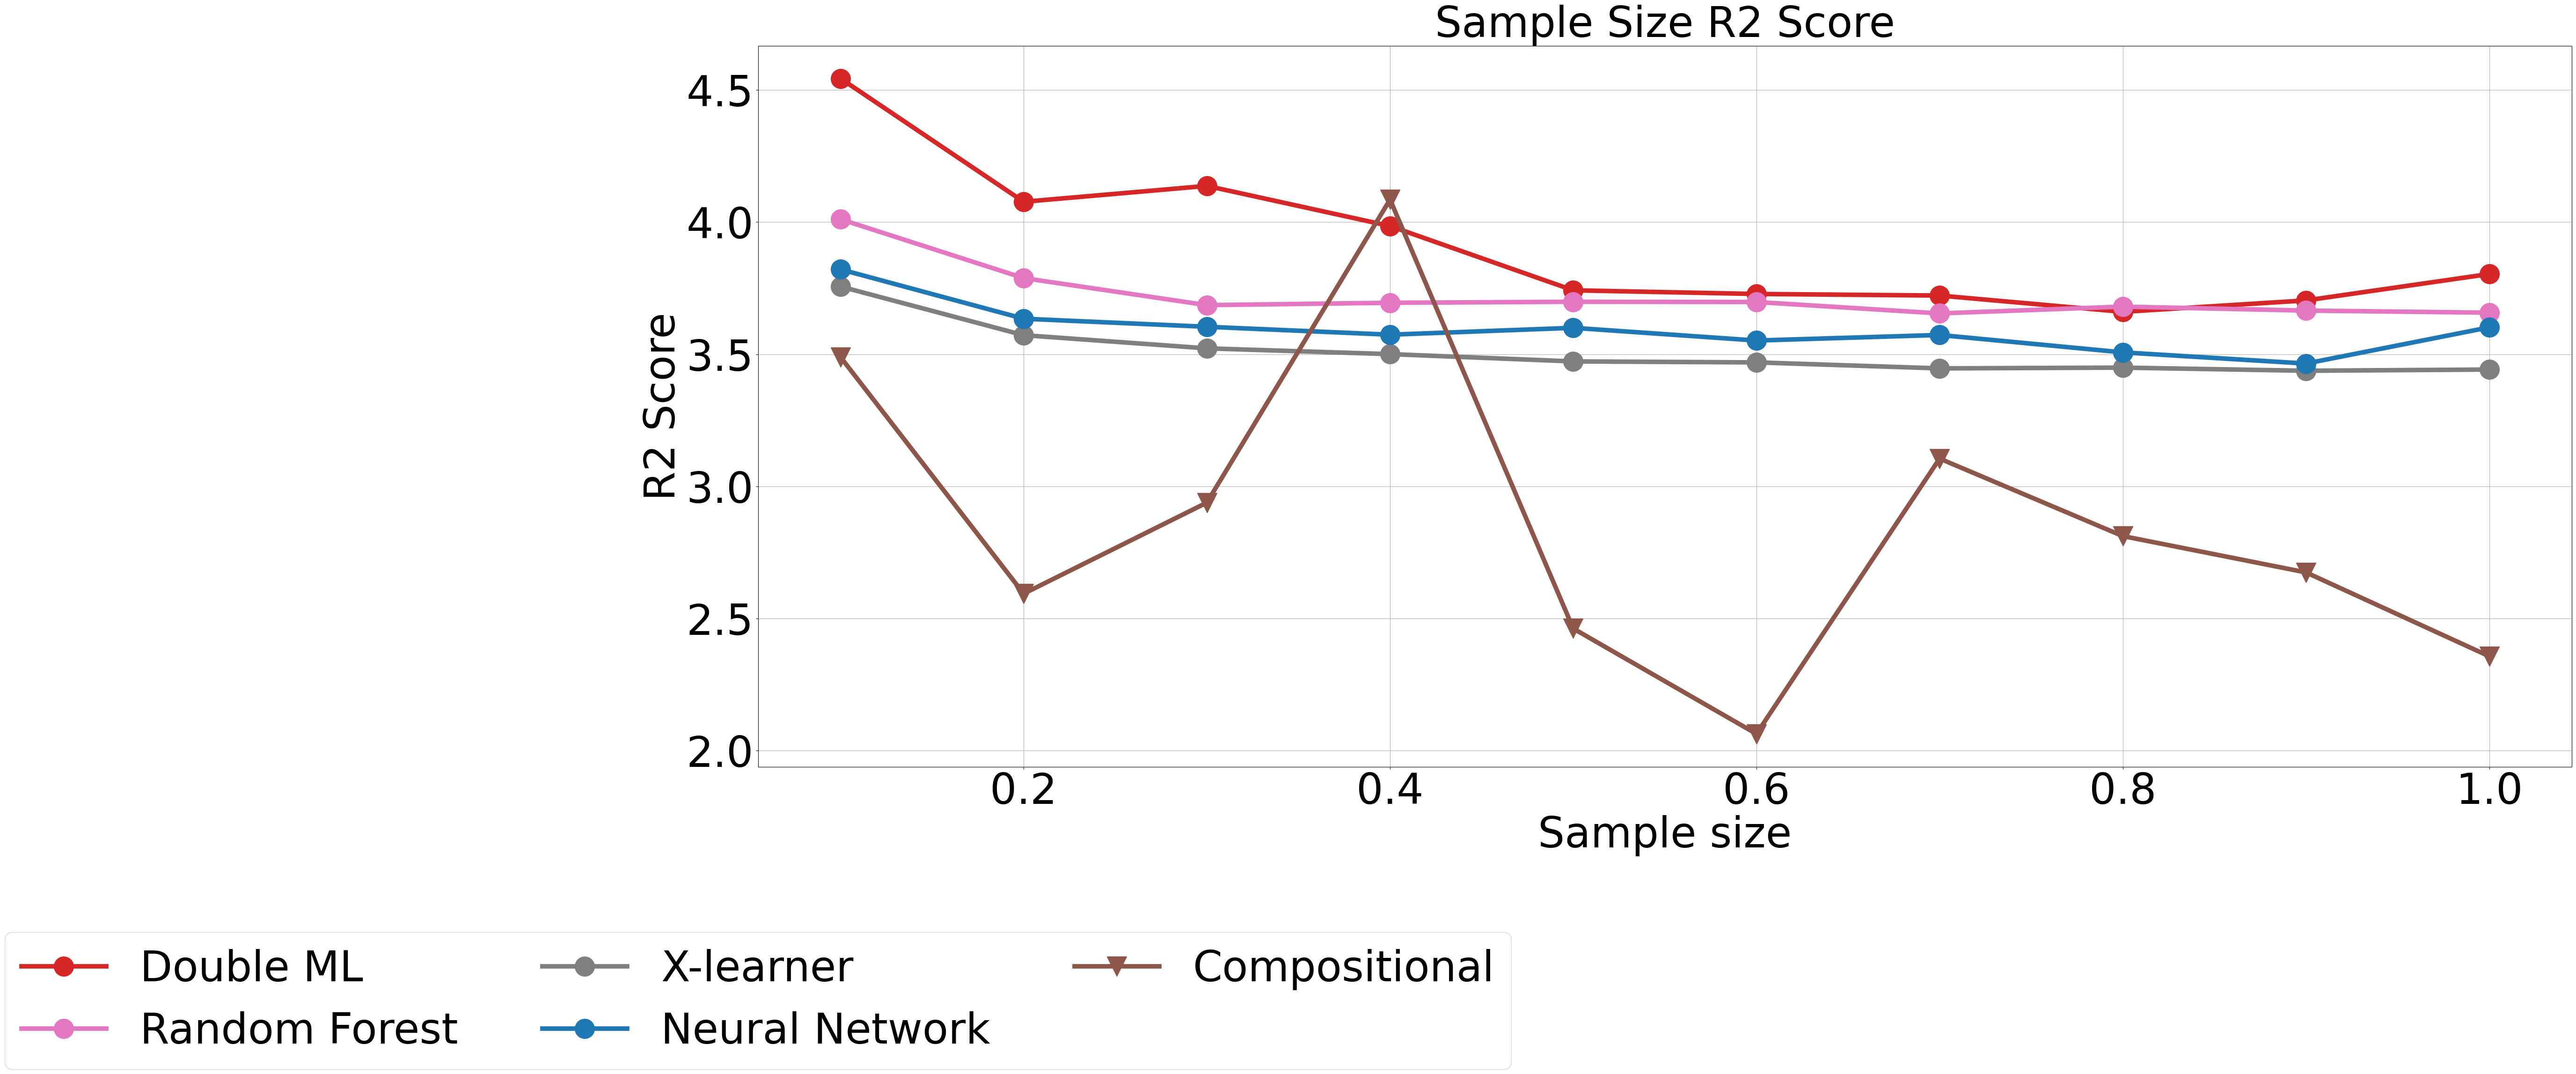

In [45]:
# have a separate plot for sample size
plt.figure(figsize=(50, 20))
for model_name in ['non_param_DML', 'random_forest','x_learner',  'neural_net', 'low_level']:
    sample_size_error = []
    sample_size_r2 = []
    for sample_size in [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]:
        label_name = label_names[model_name]
        sample_size_error.append(dictOfModels_sample_size[f'{model_name}_{variable}_{sample_size}']['error'])
        sample_size_r2.append(dictOfModels_sample_size[f'{model_name}_{variable}_{sample_size}']['r2'])

    sample_size_error_sqrt = [np.sqrt(float(x)) for x in sample_size_error]
    # have log scale
    sample_size_log = [np.log(x+1) for x in sample_size_error_sqrt]

    if model_name == 'low_level':
        marker = 'v'
    else:
        marker = 'o'
    plt.plot([0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0], sample_size_log, label=label_name, marker=marker, color=label_colors[model_name], markersize=markersize, linewidth=linewidth)
plt.xlabel('Sample size')
plt.ylabel('R2 Score')
plt.title('Sample Size R2 Score')
plt.legend(loc='upper center', bbox_to_anchor=(0, -0.2), ncol=3)
plt.grid(True)



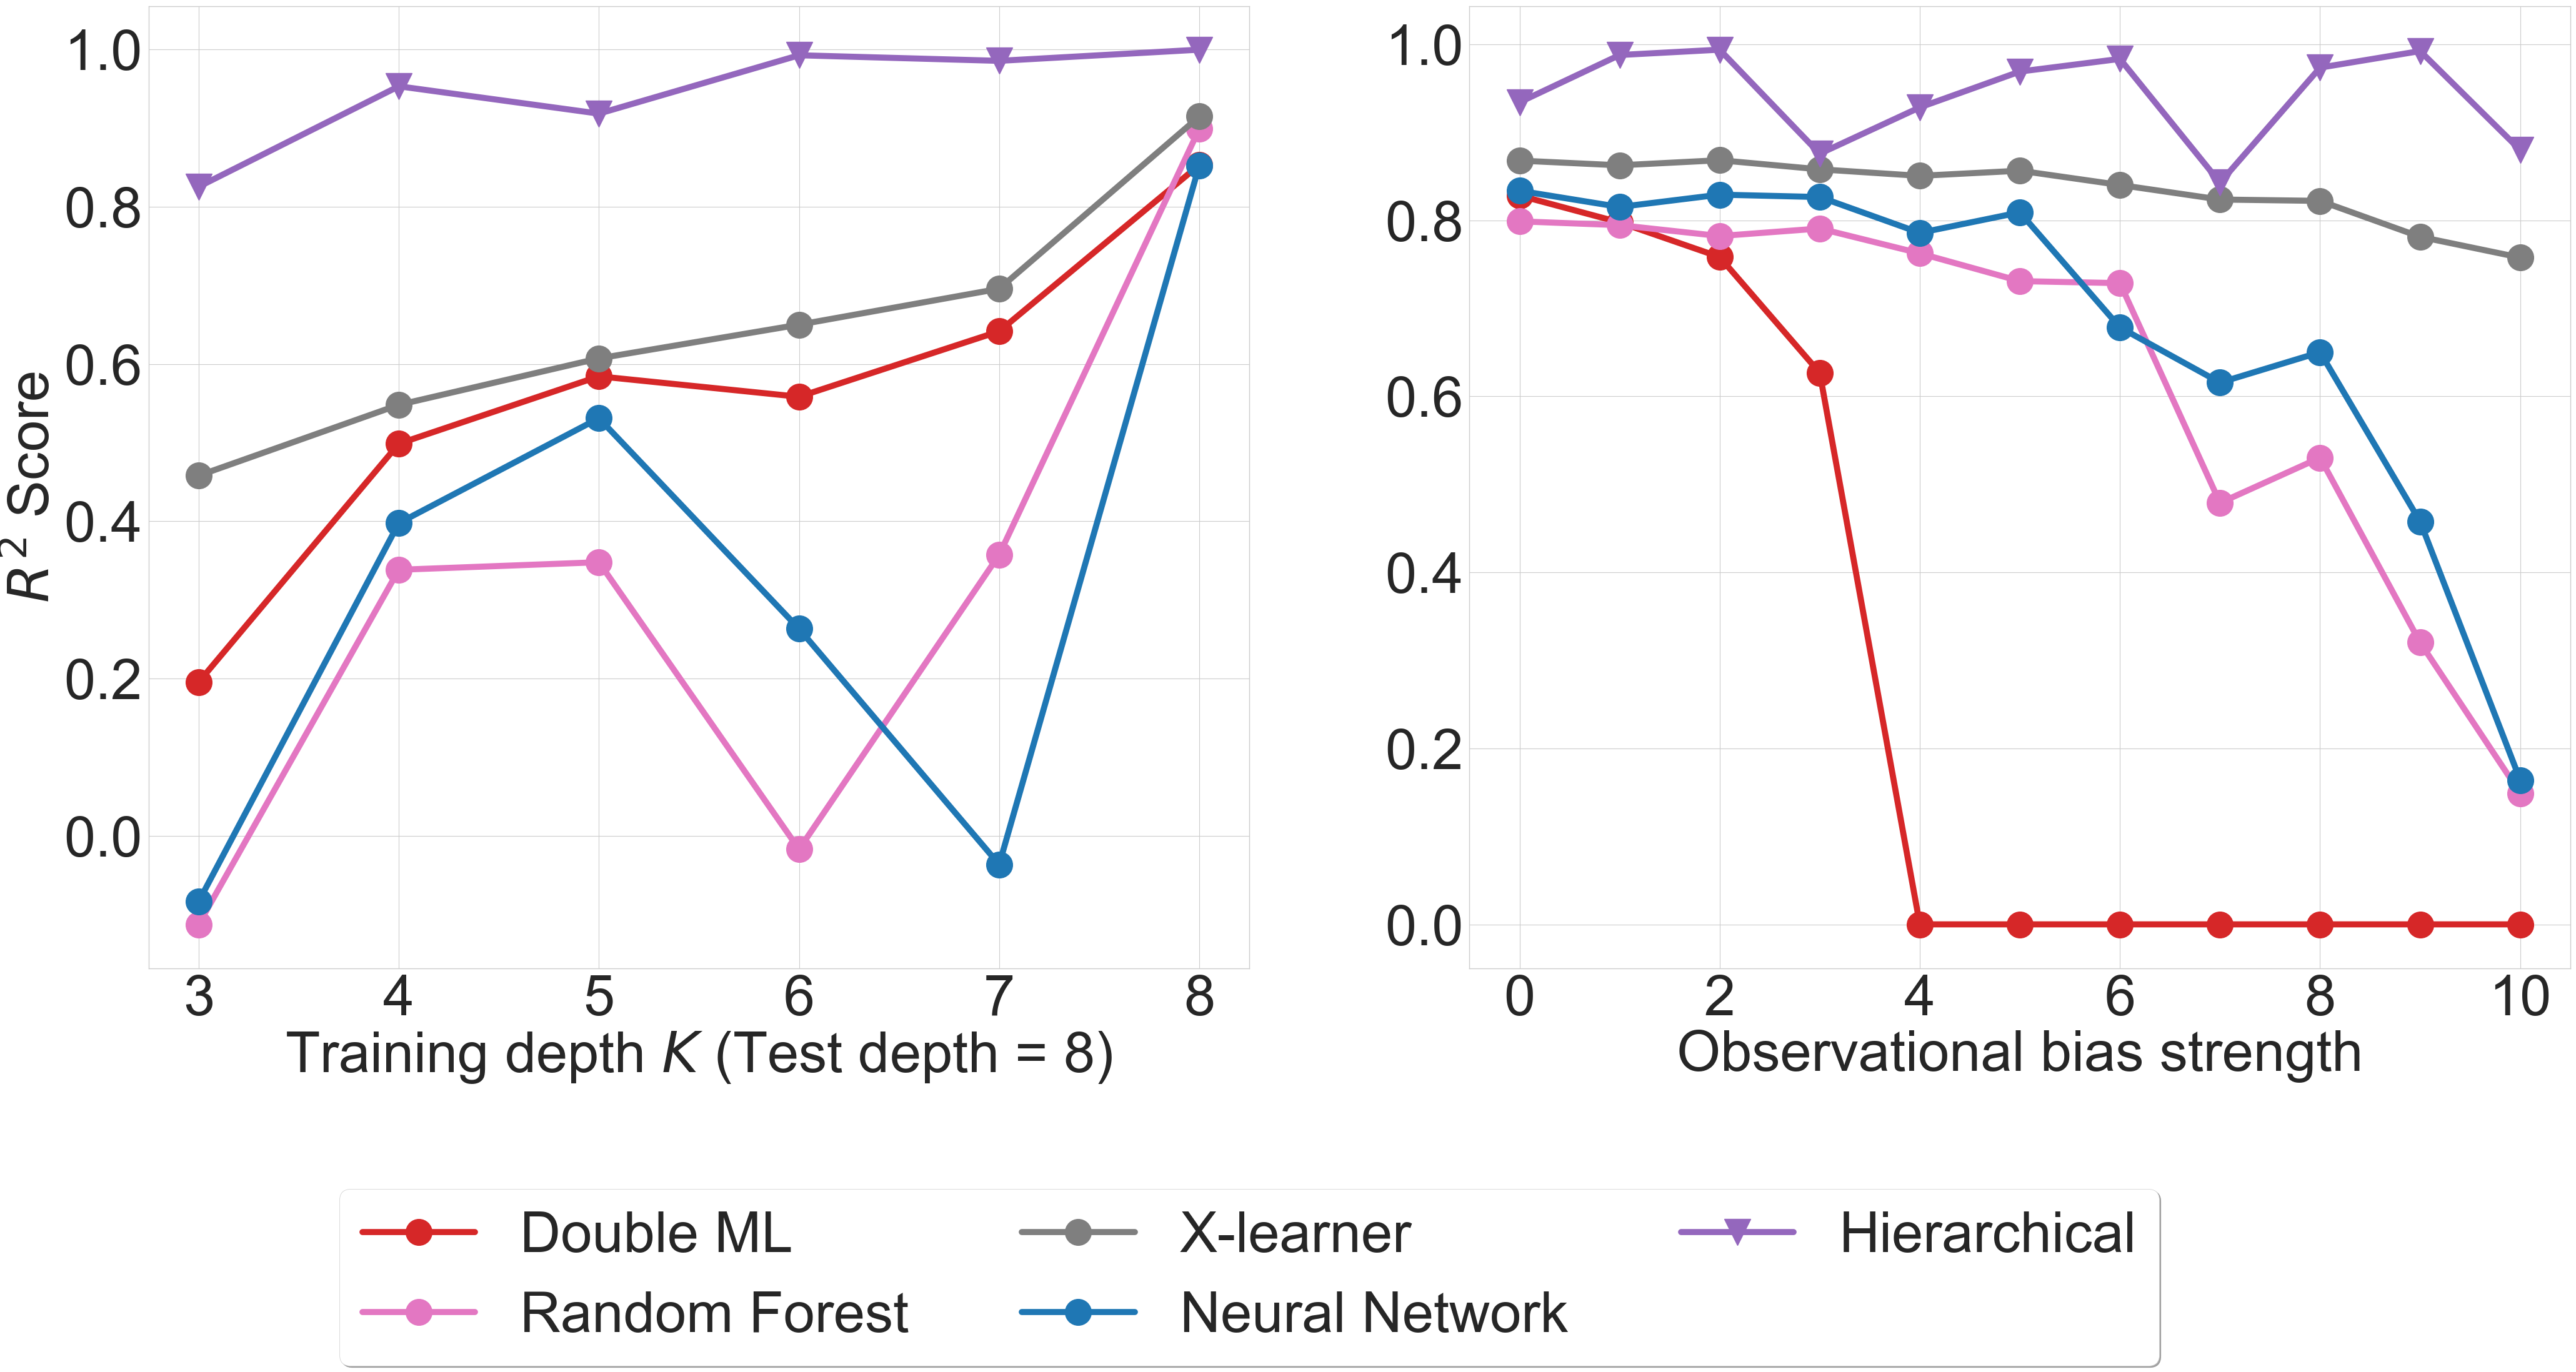

In [35]:
# whitegrid
label_colors = {"neural_network": '#1f77b4',
                "recursive_single_outcome": '#ff7f0e',
                "recursive_all_outcomes": '#2ca02c',
                "modular_single_outcome": '#17becf',
                "modular_all_outcomes": '#9467bd',
                "random_forest_additive": '#8c564b',
                "neural_network_additive": '#1f77b4',
                "x_learner": '#7f7f7f',
                "s_learner": '#bcbd22',
                "t_learner":  '#17becf',
                "random_forest": '#e377c2',
                "non_param_DML": '#d62728',
                "snet1": '#8c564b',
                "snet2": '#d62728',
                "tnet": '#bcbd22',
                "low_level": "#9467bd",
                "neural_net": '#1f77b4'}
markersize = 30
linewidth = 7
font_size = 65
# sns.set_style("whitegrid")
plt.rcParams.update({'font.size': font_size})
plt.rcParams.update({'legend.fontsize': font_size})
plt.rcParams.update({'axes.labelsize': font_size})
plt.rcParams.update({'axes.titlesize': font_size})
label_names = {'random_forest': 'Random Forest', 'x_learner': 'X-learner', 'non_param_DML': 'Double ML', 'neural_net': 'Neural Network', 'low_level': r'Hierarchical', 's_learner': 'S-learner', 't_learner': 'T-learner'}

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(50, 20))
for model_name in ['non_param_DML', 'random_forest','x_learner',  'neural_net', 'low_level']:
    depth_error = []
    depth_r2 = []
    for depth in depths:
        if model_name == 'low_level':
            variable = 'depth'
        else:
            variable = 'tree_depth'
        label_name = label_names[model_name]
        depth_error.append(dictOfModels_depth[f'{model_name}_{variable}_{int(depth)}']['error'])
        depth_r2.append(dictOfModels_depth[f'{model_name}_{variable}_{int(depth)}']['r2'])
    
    # ax1.plot(depths, error, label=f'{model_name}', marker='o')
    depth_error_sqrt = [np.sqrt(x) for x in depth_error]
    if model_name == 'low_level':
        marker = 'v'
    else:
        marker = 'o'
    ax1.plot(depths, depth_r2, label=label_name, marker=marker, color=label_colors[model_name], markersize=markersize, linewidth=linewidth)

    
    variable = 'bias_strength'
    bs_error = []
    bs_r2 = []
    for bias_strength in bias_strengths:    
        label_name = label_names[model_name]
        try:
            bs_error.append(dictOfModels_bias_strength[f'{model_name}_{variable}_{int(bias_strength)}']['error'])
            bs_r2.append(dictOfModels_bias_strength[f'{model_name}_{variable}_{int(bias_strength)}']['r2'])
        except:
            bs_error.append(0)
            bs_r2.append(0)
        
    # take root mean squared error
    
    bs_error_sqrt = [np.sqrt(float(x)) for x in bs_error]
    if model_name == 'low_level':
        marker = 'v'
    else:
        marker = 'o'
    ax2.plot(bias_strengths, bs_r2, label=label_name, marker=marker, color=label_colors[model_name], markersize=markersize, linewidth=linewidth)

# # ax1.set_title('Mean Squared Error')
ax1.set_xlabel(r'Training depth $K$ (Test depth = 8)')
ax2.set_xlabel('Observational bias strength')
# # ax1.set_ylabel('Error')
# # ax1.legend()
# ax2.set_xlabel(f'{variable}')
ax1.set_ylabel(r'$R^2$ Score')
# # set y-axis limit from 0 to 1
# ax2.set_ylim(-0.2, 1)
# legend below the graph
ax1.legend(loc='upper center', bbox_to_anchor=(1.0, -0.2), shadow=True, ncol=3)
ax1.grid(True)
ax2.grid(True)

# plt.savefig(f'r2_score_manufacturing.pdf', bbox_inches='tight')